# HW2: Word2Vec для классификации текстов (Lenta.ru News)

**Задача:** Классификация новостных статей по тематическим категориям с использованием word embeddings

**Датасет:** lenta-ru-news (переиспользуем подготовку из HW1)

---

## 0. Настройка окружения и импорты

In [1]:
# Фиксируем random_state для воспроизводимости
RANDOM_STATE = 42

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Фиксируем seed
np.random.seed(RANDOM_STATE)

In [2]:
from functools import lru_cache

from corus import load_lenta2

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

import re
import pymorphy3
import nltk

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Word2Vec и эмбеддинги
from gensim.models import Word2Vec, KeyedVectors

RUSSIAN_STOPWORDS = set(stopwords.words('russian'))

## 1. Загрузка и подготовка данных (из HW1)

In [3]:
DATA_PATH = 'lenta-ru-news.csv.bz2'

records = list(tqdm(load_lenta2(DATA_PATH), desc='Загрузка данных'))
print(f'Всего записей: {len(records):,}')

Загрузка данных: 0it [00:00, ?it/s]

Загрузка данных: 800975it [00:46, 17235.56it/s]

Всего записей: 800,975


In [4]:
df = pd.DataFrame([
    {
        'title': r.title,
        'text': r.text,
        'topic': r.topic
    }
    for r in records
])

print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (800975, 3)


,title,text,topic
0,1914. Русские войска вступили в пределы Венгрии,Бои у Сопоцкина и Друскеник закончились отступ...,Библиотека
1,1914. Празднование столетия М.Ю. Лермонтова от...,"Министерство народного просвещения, в виду про...",Библиотека
2,1914. Das ist Nesteroff!,"Штабс-капитан П. Н. Нестеров на днях, увидев в...",Библиотека
3,1914. Бульдог-гонец под Льежем,Фотограф-корреспондент Daily Mirror рассказыва...,Библиотека
4,1914. Под Люблином пойман швабский зверь,"Лица, приехавшие в Варшаву из Люблина, передаю...",Библиотека


### Фильтрация данных

Переиспользуем логику из HW1:
- Удаляем тексты без топиков (~70k)
- Удаляем редкие классы (<6000 текстов)
- Фильтруем выбросы по длине (5-95 перцентиль)

In [5]:
# Удаляем пустые топики и редкие классы
MIN_CLASS_THRESHOLD = 6000

topic_counts = df['topic'].value_counts()
valid_topics = topic_counts[topic_counts >= MIN_CLASS_THRESHOLD].index

df_filtered = df[(df['topic'] != '') & (df['topic'].isin(valid_topics))].copy()
print(f'После удаления пустых топиков и редких классов: {len(df_filtered):,}')

После удаления пустых топиков и редких классов: 736,513


In [6]:
# Фильтрация по длине текста (5-95 перцентиль)
df_filtered['text_len'] = df_filtered['text'].str.len()

q05, q95 = df_filtered['text_len'].quantile([0.05, 0.95])
df_filtered = df_filtered[(df_filtered['text_len'] >= q05) & (df_filtered['text_len'] <= q95)]

print(f'После фильтрации по длине: {len(df_filtered):,}')

После фильтрации по длине: 662,936


In [7]:
# Стратифицированная выборка 100k текстов
SAMPLE_SIZE = 100_000

df_sample, _ = train_test_split(
    df_filtered, 
    train_size=SAMPLE_SIZE, 
    stratify=df_filtered['topic'],
    random_state=RANDOM_STATE
)

print(f'Размер выборки: {len(df_sample):,}')
print(f'\nРаспределение по топикам:')
print(df_sample['topic'].value_counts())

Размер выборки: 100,000

Распределение по топикам:
topic
Россия               20798
Мир                  18452
Экономика            11124
Спорт                 9154
Культура              7531
Наука и техника       7304
Бывший СССР           6828
Интернет и СМИ        6158
Из жизни              3833
Дом                   3059
Силовые структуры     2748
Ценности              1134
Бизнес                 958
Путешествия            919
Name: count, dtype: int64


## 2. Предобработка текстов (из HW1)

In [8]:
# Инициализация морфологического анализатора
morph = pymorphy3.MorphAnalyzer()

# Компилируем регулярные выражения заранее
URL_PATTERN = re.compile(r'https?://\S+|www\.\S+')
EMAIL_PATTERN = re.compile(r'\S+@\S+')
NUMBERS_PATTERN = re.compile(r'\d+')
PUNCTUATION_PATTERN = re.compile(r'[^\w\s]')
WHITESPACE_PATTERN = re.compile(r'\s+')


@lru_cache(maxsize=500_000)
def lemmatize_word(word: str) -> str:
    """Лемматизация с кэшированием через lru_cache.
    
    maxsize=500_000 — ожидаемый размер словаря (~425k уникальных слов в HW1).
    lru_cache автоматически управляет памятью и вытесняет редко используемые элементы.
    """
    return morph.parse(word)[0].normal_form


def preprocess_text(text: str) -> str:
    """Полный пайплайн предобработки текста."""
    if not isinstance(text, str):
        return ''
    
    # Приводим к нижнему регистру
    text = text.lower()
    
    # Удаляем URL, email, числа
    text = URL_PATTERN.sub(' ', text)
    text = EMAIL_PATTERN.sub(' ', text)
    text = NUMBERS_PATTERN.sub(' ', text)
    
    # Удаляем пунктуацию
    text = PUNCTUATION_PATTERN.sub(' ', text)
    
    # Токенизация
    tokens = text.split()
    
    # Фильтрация стоп-слов и коротких токенов + лемматизация
    tokens = [
        lemmatize_word(token) 
        for token in tokens 
        if token not in RUSSIAN_STOPWORDS and len(token) > 2
    ]
    
    return ' '.join(tokens)


def preprocess_text_to_tokens(text: str) -> list:
    """Предобработка с возвратом списка токенов (для Word2Vec)."""
    return preprocess_text(text).split()

In [9]:
# Предобработка ПОЛНОГО датасета для обучения Word2Vec
# (Word2Vec обучается unsupervised, поэтому используем все данные)
print('Предобработка полного датасета для Word2Vec...')
tqdm.pandas(desc='Предобработка полного датасета')

df_filtered['full_text'] = df_filtered['title'] + ' ' + df_filtered['text']
df_filtered['processed_text'] = df_filtered['full_text'].progress_apply(preprocess_text)
df_filtered['tokens'] = df_filtered['processed_text'].apply(str.split)

print(f'Полный датасет предобработан: {len(df_filtered):,} текстов')

# Обновляем df_sample предобработанными данными из df_filtered
# (df_sample - подмножество df_filtered, берём по индексам)
df_sample = df_sample.copy()
df_sample['full_text'] = df_filtered.loc[df_sample.index, 'full_text']
df_sample['processed_text'] = df_filtered.loc[df_sample.index, 'processed_text']
df_sample['tokens'] = df_filtered.loc[df_sample.index, 'tokens']

print(f'Выборка 100k обновлена предобработанными данными')

# Статистика кэша лемматизации
cache_info = lemmatize_word.cache_info()
print(f'Кэш лемматизации: hits={cache_info.hits:,}, misses={cache_info.misses:,}, size={cache_info.currsize:,}')

Предобработка полного датасета для Word2Vec...


Предобработка полного датасета: 100%|██████████| 662936/662936 [03:00<00:00, 3673.31it/s]


Полный датасет предобработан: 662,936 текстов
Выборка 100k обновлена предобработанными данными
Кэш лемматизации: hits=87,208,162, misses=1,208,479, size=500,000


In [10]:
# Кодируем целевую переменную
label_encoder = LabelEncoder()
df_sample['label'] = label_encoder.fit_transform(df_sample['topic'])

print('Маппинг классов:')
for i, cls in enumerate(label_encoder.classes_):
    print(f'{i}: {cls}')

Маппинг классов:
0: Бизнес
1: Бывший СССР
2: Дом
3: Из жизни
4: Интернет и СМИ
5: Культура
6: Мир
7: Наука и техника
8: Путешествия
9: Россия
10: Силовые структуры
11: Спорт
12: Ценности
13: Экономика


## 3. Разделение на train/val/test (60/20/20)

In [11]:
X_text = df_sample['processed_text'].values
X_tokens = df_sample['tokens'].values
y = df_sample['label'].values

# Сначала отделяем test (20%)
X_text_temp, X_text_test, X_tokens_temp, X_tokens_test, y_temp, y_test = train_test_split(
    X_text, X_tokens, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=RANDOM_STATE
)

# Затем делим оставшиеся 80% на train (60%) и val (20%)
X_text_train, X_text_val, X_tokens_train, X_tokens_val, y_train, y_val = train_test_split(
    X_text_temp, X_tokens_temp, y_temp, 
    test_size=0.25,  # 0.25 * 0.8 = 0.2
    stratify=y_temp, 
    random_state=RANDOM_STATE
)

print(f'Train: {len(X_text_train):,} ({len(X_text_train)/len(X_text)*100:.0f}%)')
print(f'Val:   {len(X_text_val):,} ({len(X_text_val)/len(X_text)*100:.0f}%)')
print(f'Test:  {len(X_text_test):,} ({len(X_text_test)/len(X_text)*100:.0f}%)')

Train: 60,000 (60%)
Val:   20,000 (20%)
Test:  20,000 (20%)


---

## 4. Обучение Word2Vec эмбеддингов (gensim)

**Важно:** Word2Vec обучается на **полном датасете** (~663k текстов), а не только на train выборке.
Это стандартная практика: эмбеддинги обучаются unsupervised, поэтому использование всех данных не создаёт data leakage.
Классификатор при этом обучается на 100k выборке (как в HW1) для корректного сравнения.

### Выбор гиперпараметров:

| Параметр | Значение | Обоснование |
|----------|----------|-------------|
| `vector_size` | 300 | Увеличили с 200 до 300 для большего корпуса, совпадает с предобученными моделями |
| `window` | 10 | Большое окно для захвата тематической близости (важно для классификации по топикам) |
| `min_count` | 5 | Отсекаем редкие слова (<5 вхождений), которые не дадут качественных векторов |
| `sg` | 1 (Skip-gram) | Лучше работает на корпусах среднего размера, качественнее для редких слов |
| `epochs` | 10 | Стандартное значение, достаточное для сходимости |
| `negative` | 5 | Negative sampling — эффективнее hierarchical softmax для нашего размера словаря |

In [12]:
# Подготовка данных для Word2Vec: используем ПОЛНЫЙ датасет
# Это даёт более качественные эмбеддинги за счёт большего количества контекстов
all_sentences = df_filtered['tokens'].tolist()

print(f'Количество документов для обучения Word2Vec: {len(all_sentences):,}')
print(f'Пример токенов: {all_sentences[0][:10]}')

Количество документов для обучения Word2Vec: 662,936
Пример токенов: ['космонавт', 'сомневаться', 'надёжность', 'мир', 'стать', 'известно', 'агентство', 'ассошиэйтед', 'пресс', 'экипаж']


In [13]:
# Обучение Word2Vec на полном датасете
w2v_model = Word2Vec(
    sentences=all_sentences,
    vector_size=300,    # размерность вектора (как у предобученных моделей)
    window=10,          # размер контекстного окна
    min_count=5,        # минимальная частота слова
    sg=1,               # Skip-gram
    epochs=10,          # количество эпох
    negative=5,         # negative sampling
    workers=4,          # параллелизация
    seed=RANDOM_STATE   # воспроизводимость
)

print(f'Размер словаря: {len(w2v_model.wv):,}')
print(f'Размерность векторов: {w2v_model.wv.vector_size}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Размер словаря: 165,484
Размерность векторов: 300


### Визуальная оценка качества эмбеддингов (intrinsic evaluation)

In [14]:
# most_similar: проверяем семантическую близость
test_words = ['россия', 'президент', 'футбол', 'экономика', 'интернет']

print('=== most_similar ===' )
for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        similar_words = [f"{w} ({s:.2f})" for w, s in similar]
        print(f'\n{word}: {similar_words}')
    else:
        print(f'\n{word}: не найдено в словаре')

=== most_similar ===

россия: ['российский (0.71)', 'страна (0.63)', 'москва (0.58)', 'март (0.55)', 'заявить (0.55)']

президент: ['путин (0.71)', 'трамп (0.63)', 'глава (0.61)', 'государство (0.58)', 'президентский (0.57)']

футбол: ['футбольный (0.73)', 'чемпионат (0.71)', 'фифа (0.70)', 'сборная (0.70)', 'мундиаль (0.68)']

экономика: ['ввп (0.74)', 'рецессия (0.71)', 'экономический (0.67)', 'экономист (0.64)', 'макроэкономический (0.63)']

интернет: ['сеть (0.66)', 'пользователь (0.64)', 'онлайн (0.64)', 'соцсеть (0.61)', 'рунет (0.58)']


In [15]:
# doesnt_match: находим лишнее слово в группе
print('=== doesnt_match ===')

test_groups = [
    ['москва', 'петербург', 'новосибирск', 'футбол'],  # города + спорт
    ['рубль', 'доллар', 'евро', 'президент'],          # валюты + политика
    ['футбол', 'хоккей', 'теннис', 'экономика'],       # спорт + экономика
    ['путин', 'медведев', 'обама', 'газпром'],         # политики + компания
]

for group in test_groups:
    # Проверяем, что все слова есть в словаре
    group_in_vocab = [w for w in group if w in w2v_model.wv]
    if len(group_in_vocab) == len(group):
        odd_one = w2v_model.wv.doesnt_match(group)
        print(f'{group} -> лишнее: {odd_one}')
    else:
        missing = set(group) - set(group_in_vocab)
        print(f'{group} -> не все слова в словаре: {missing}')

=== doesnt_match ===
['москва', 'петербург', 'новосибирск', 'футбол'] -> лишнее: футбол
['рубль', 'доллар', 'евро', 'президент'] -> лишнее: президент
['футбол', 'хоккей', 'теннис', 'экономика'] -> лишнее: экономика
['путин', 'медведев', 'обама', 'газпром'] -> лишнее: газпром


In [16]:
# Аналогии: король - мужчина + женщина = королева
print('=== Аналогии ===')

analogies = [
    ('москва', 'россия', 'париж'),      # столица -> страна
    ('путин', 'россия', 'обама'),       # президент -> страна
    ('рубль', 'россия', 'доллар'),      # валюта -> страна
]

for positive1, negative, positive2 in analogies:
    try:
        # positive2 - negative + positive1 = ?
        result = w2v_model.wv.most_similar(
            positive=[positive1, positive2], 
            negative=[negative], 
            topn=3
        )
        print(f'{positive1} - {negative} + {positive2} = {[w for w, _ in result]}')
    except KeyError as e:
        print(f'Слово не найдено: {e}')

=== Аналогии ===
москва - россия + париж = ['парижский', 'столица', 'лондон']
путин - россия + обама = ['барак', 'трамп', 'буш']
рубль - россия + доллар = ['стоимость', 'сумма', 'евро']


---

## 5. Загрузка предобученных эмбеддингов

### 5.1 Navec

In [17]:
from navec import Navec

NAVEC_PATH = 'navec_hudlit_v1_12B_500K_300d_100q.tar'

navec = Navec.load(NAVEC_PATH)

print(f'Navec загружен')
print(f'Размер словаря: {len(navec.vocab.words):,}')
print(f'Размерность: {navec.pq.dim}')

Navec загружен
Размер словаря: 500,002
Размерность: 300


### 5.2 RusVectores (корпус Taiga)

Модель из проекта [RusVectores](https://rusvectores.org/), обученная на корпусе **Taiga** — большом русском корпусе (4.8B токенов), включающем:
- Новости
- Художественную прозу
- Социальные сети
- Субтитры

Источник: [NLPL Word Vectors Repository](http://vectors.nlpl.eu/repository/) (модель #185, `tayga_upos_skipgram_300_2_2019`)

In [18]:
RUSVECTORES_PATH = 'model.bin'  # модель RusVectores, обученная на корпусе Taiga (185.zip)

rusvectores = KeyedVectors.load_word2vec_format(RUSVECTORES_PATH, binary=True)

print(f'RusVectores (Taiga) загружен')
print(f'Размер словаря: {len(rusvectores):,}')
print(f'Размерность: {rusvectores.vector_size}')

RusVectores (Taiga) загружен
Размер словаря: 249,565
Размерность: 300


---

## 6. Векторизация текстов через эмбеддинги

Для представления текста как вектора используем **усреднение эмбеддингов** всех слов текста.

Результаты кэшируются на диск в папку `.cache/` для ускорения повторных запусков.

In [19]:
import os
from joblib import dump, load

CACHE_DIR = '.cache'
os.makedirs(CACHE_DIR, exist_ok=True)


def text_to_vector_w2v(tokens: list, model, vector_size: int) -> np.ndarray:
    """Усреднение word2vec эмбеддингов слов текста."""
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)


def text_to_vector_navec(tokens: list, model, vector_size: int) -> np.ndarray:
    """Усреднение navec эмбеддингов слов текста."""
    vectors = [model[token] for token in tokens if token in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)


def text_to_vector_rv(tokens: list, model: KeyedVectors, vector_size: int) -> np.ndarray:
    """Усреднение KeyedVectors эмбеддингов (RusVectores с POS-тегами)."""
    vectors = []
    pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN']
    
    for token in tokens:
        # Пробуем найти слово с разными POS-тегами
        for pos in pos_tags:
            if f'{token}_{pos}' in model:
                vectors.append(model[f'{token}_{pos}'])
                break
        else:
            # Если не нашли с POS, пробуем без
            if token in model:
                vectors.append(model[token])
    
    return np.mean(vectors, axis=0) if vectors else np.zeros(vector_size)


def vectorize_dataset(tokens_list, model, model_type: str, vector_size: int, cache_name: str) -> np.ndarray:
    """
    Векторизация списка текстов с кэшированием.
    
    Args:
        tokens_list: список списков токенов
        model: модель эмбеддингов (Word2Vec, Navec или RusVectors)
        model_type: 'w2v', 'navec' или 'rusvectores'
        vector_size: размерность вектора
        cache_name: имя файла кэша
    """
    cache_path = os.path.join(CACHE_DIR, f'{cache_name}.joblib')
    
    if os.path.exists(cache_path):
        print(f'Загрузка из кэша: {cache_name}')
        return load(cache_path)
    
    print(f'Векторизация {cache_name}...')
    
    # Выбираем функцию векторизации
    if model_type == 'w2v':
        vectorize_func = lambda tokens: text_to_vector_w2v(tokens, model, vector_size)
    elif model_type == 'navec':
        vectorize_func = lambda tokens: text_to_vector_navec(tokens, model, vector_size)
    else:  # rusvectores
        vectorize_func = lambda tokens: text_to_vector_rv(tokens, model, vector_size)
    
    vectors = np.array([vectorize_func(tokens) for tokens in tqdm(tokens_list)])
    
    dump(vectors, cache_path)
    print(f'Сохранено: {cache_name}')
    
    return vectors

In [20]:
# Векторизация с помощью нашего Word2Vec
print('=== Word2Vec (наш, обучен на 663k текстов) ===')

X_train_w2v = vectorize_dataset(X_tokens_train, w2v_model, 'w2v', 300, 'X_train_w2v_full')
X_val_w2v = vectorize_dataset(X_tokens_val, w2v_model, 'w2v', 300, 'X_val_w2v_full')
X_test_w2v = vectorize_dataset(X_tokens_test, w2v_model, 'w2v', 300, 'X_test_w2v_full')

print(f'Shape: train={X_train_w2v.shape}, val={X_val_w2v.shape}, test={X_test_w2v.shape}')

=== Word2Vec (наш, обучен на 663k текстов) ===
Загрузка из кэша: X_train_w2v_full
Загрузка из кэша: X_val_w2v_full
Загрузка из кэша: X_test_w2v_full
Shape: train=(60000, 300), val=(20000, 300), test=(20000, 300)


In [21]:
# Векторизация с помощью Navec
print('=== Navec ===')

X_train_navec = vectorize_dataset(X_tokens_train, navec, 'navec', 300, 'X_train_navec')
X_val_navec = vectorize_dataset(X_tokens_val, navec, 'navec', 300, 'X_val_navec')
X_test_navec = vectorize_dataset(X_tokens_test, navec, 'navec', 300, 'X_test_navec')

print(f'Shape: train={X_train_navec.shape}, val={X_val_navec.shape}, test={X_test_navec.shape}')

=== Navec ===
Загрузка из кэша: X_train_navec
Загрузка из кэша: X_val_navec
Загрузка из кэша: X_test_navec
Shape: train=(60000, 300), val=(20000, 300), test=(20000, 300)


In [22]:
# Векторизация с помощью RusVectores
print('=== RusVectores (Taiga) ===')

X_train_rusv = vectorize_dataset(X_tokens_train, rusvectores, 'rusvectores', 300, 'X_train_rusv_taiga')
X_val_rusv = vectorize_dataset(X_tokens_val, rusvectores, 'rusvectores', 300, 'X_val_rusv_taiga')
X_test_rusv = vectorize_dataset(X_tokens_test, rusvectores, 'rusvectores', 300, 'X_test_rusv_taiga')

print(f'Shape: train={X_train_rusv.shape}, val={X_val_rusv.shape}, test={X_test_rusv.shape}')

=== RusVectores (Taiga) ===
Загрузка из кэша: X_train_rusv_taiga
Загрузка из кэша: X_val_rusv_taiga
Загрузка из кэша: X_test_rusv_taiga
Shape: train=(60000, 300), val=(20000, 300), test=(20000, 300)


---

## 7. Обучение LogisticRegression с разными эмбеддингами

In [23]:
def train_and_evaluate(X_train, X_val, y_train, y_val, name: str):
    """Обучение LogisticRegression и оценка на валидации."""
    model = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
        n_jobs=-1,
        class_weight='balanced'  # для несбалансированных классов
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average='macro')
    f1_weighted = f1_score(y_val, y_pred, average='weighted')
    
    print(f'=== {name} ===')
    print(f'Accuracy:    {acc:.4f}')
    print(f'F1 Macro:    {f1_macro:.4f}')
    print(f'F1 Weighted: {f1_weighted:.4f}')
    print()
    
    return model, {'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted}

In [24]:
# Сравнение на валидации
results_val = {}

model_w2v, results_val['Word2Vec (наш)'] = train_and_evaluate(
    X_train_w2v, X_val_w2v, y_train, y_val, 'Word2Vec (наш)'
)

model_navec, results_val['Navec'] = train_and_evaluate(
    X_train_navec, X_val_navec, y_train, y_val, 'Navec'
)

model_rusv, results_val['RusVectores'] = train_and_evaluate(
    X_train_rusv, X_val_rusv, y_train, y_val, 'RusVectores'
)

=== Word2Vec (наш) ===
Accuracy:    0.7654
F1 Macro:    0.7143
F1 Weighted: 0.7774

=== Navec ===
Accuracy:    0.7212
F1 Macro:    0.6689
F1 Weighted: 0.7354

=== RusVectores ===
Accuracy:    0.7282
F1 Macro:    0.6762
F1 Weighted: 0.7419



In [25]:
# Сводная таблица результатов на валидации
results_df = pd.DataFrame(results_val).T
results_df = results_df.sort_values('f1_macro', ascending=False)
print('Сравнение эмбеддингов на валидации:')
print(results_df.to_string())

Сравнение эмбеддингов на валидации:
                accuracy  f1_macro  f1_weighted
Word2Vec (наш)   0.76540  0.714310     0.777400
RusVectores      0.72825  0.676230     0.741914
Navec            0.72120  0.668872     0.735350


---

## 8. TF-IDF взвешивание эмбеддингов

Вместо простого усреднения используем **взвешенное усреднение**, где вес каждого слова — его TF-IDF коэффициент.

In [26]:
# Обучаем TF-IDF на тренировочных данных
tfidf = TfidfVectorizer()
tfidf.fit(X_text_train)

# Создаем словарь: слово -> индекс
word_to_idx = tfidf.vocabulary_

print(f'Размер TF-IDF словаря: {len(word_to_idx):,}')

Размер TF-IDF словаря: 154,369


In [36]:
def text_to_vector_tfidf_weighted(text: str, tokens: list, model, vector_size: int, 
                                   tfidf_vectorizer, word_to_idx: dict,
                                   get_vector_func) -> np.ndarray:
    """
    TF-IDF взвешенное усреднение эмбеддингов.
    
    Args:
        text: предобработанный текст (строка)
        tokens: список токенов
        model: модель эмбеддингов
        vector_size: размерность вектора
        tfidf_vectorizer: обученный TfidfVectorizer
        word_to_idx: словарь слово -> индекс
        get_vector_func: функция получения вектора слова из модели
    """
    # Получаем TF-IDF вектор для текста
    tfidf_vector = tfidf_vectorizer.transform([text]).toarray()[0]

    # Вычисляем средний вес для OOV слов (вместо 1.0, который был слишком большим)                                                                                                                                                                                               
    nonzero_weights = tfidf_vector[tfidf_vector > 0]                                                                                                                               
    avg_weight = np.mean(nonzero_weights) if len(nonzero_weights) > 0 else 0.1   
    
    weighted_vectors = []
    weights = []
    
    for token in tokens:
        vector = get_vector_func(token, model)
        if vector is not None:
            # Получаем TF-IDF вес слова
            if token in word_to_idx:
                weight = tfidf_vector[word_to_idx[token]]
            else:
                weight = avg_weight  # если слова нет в TF-IDF словаре, используем средний вес
            
            weighted_vectors.append(vector * weight)
            weights.append(weight)
    
    if weighted_vectors:
        # Взвешенное среднее
        return np.sum(weighted_vectors, axis=0) / (np.sum(weights) + 1e-8)
    else:
        return np.zeros(vector_size)


# Функции получения векторов для разных моделей
def get_vector_w2v(token, model):
    if token in model.wv:
        return model.wv[token]
    return None

def get_vector_navec(token, model):
    if token in model:
        return model[token]
    return None

def get_vector_rusv(token, model):
    pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN']
    for pos in pos_tags:
        word_pos = f'{token}_{pos}'
        if word_pos in model:
            return model[word_pos]
    if token in model:
        return model[token]
    return None

In [37]:
# Определяем лучшую модель по валидации
best_model_name = results_df.index[0]
print(f'Лучшая модель: {best_model_name}')
print('Применяем TF-IDF взвешивание к лучшей модели...')

Лучшая модель: Word2Vec (наш)
Применяем TF-IDF взвешивание к лучшей модели...


In [38]:
# Выбираем модель и функцию для TF-IDF взвешивания
if 'Word2Vec' in best_model_name:
    emb_model = w2v_model
    vector_size = 300
    get_vector_func = get_vector_w2v
elif 'Navec' in best_model_name:
    emb_model = navec
    vector_size = 300
    get_vector_func = get_vector_navec
else:  # RusVectores
    emb_model = rusvectores
    vector_size = rusvectores.vector_size
    get_vector_func = get_vector_rusv

# Векторизация с TF-IDF взвешиванием
print('Векторизация с TF-IDF взвешиванием...')

X_train_tfidf_w = np.array([
    text_to_vector_tfidf_weighted(text, tokens, emb_model, vector_size, tfidf, word_to_idx, get_vector_func)
    for text, tokens in tqdm(zip(X_text_train, X_tokens_train), total=len(X_text_train))
])

X_val_tfidf_w = np.array([
    text_to_vector_tfidf_weighted(text, tokens, emb_model, vector_size, tfidf, word_to_idx, get_vector_func)
    for text, tokens in tqdm(zip(X_text_val, X_tokens_val), total=len(X_text_val))
])

X_test_tfidf_w = np.array([
    text_to_vector_tfidf_weighted(text, tokens, emb_model, vector_size, tfidf, word_to_idx, get_vector_func)
    for text, tokens in tqdm(zip(X_text_test, X_tokens_test), total=len(X_text_test))
])

print(f'Shape: train={X_train_tfidf_w.shape}, val={X_val_tfidf_w.shape}, test={X_test_tfidf_w.shape}')

Векторизация с TF-IDF взвешиванием...


100%|██████████| 20000/20000 [00:12<00:00, 1605.51it/s]

Shape: train=(60000, 300), val=(20000, 300), test=(20000, 300)


In [39]:
# Обучение с TF-IDF взвешиванием
model_tfidf_w, results_val[f'{best_model_name} + TF-IDF'] = train_and_evaluate(
    X_train_tfidf_w, X_val_tfidf_w, y_train, y_val, f'{best_model_name} + TF-IDF'
)

=== Word2Vec (наш) + TF-IDF ===
Accuracy:    0.7365
F1 Macro:    0.6787
F1 Weighted: 0.7504



---

## 9. Финальное сравнение на тестовой выборке

In [40]:
def evaluate_on_test(model, X_test, y_test, name: str):
    """Оценка модели на тестовой выборке."""
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    return {'accuracy': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted}

In [41]:
# Оценка всех моделей на тесте
results_test = {}

results_test['Word2Vec (наш)'] = evaluate_on_test(model_w2v, X_test_w2v, y_test, 'Word2Vec (наш)')
results_test['Navec'] = evaluate_on_test(model_navec, X_test_navec, y_test, 'Navec')
results_test['RusVectores'] = evaluate_on_test(model_rusv, X_test_rusv, y_test, 'RusVectores')
results_test[f'{best_model_name} + TF-IDF'] = evaluate_on_test(model_tfidf_w, X_test_tfidf_w, y_test, f'{best_model_name} + TF-IDF')

In [42]:
# Финальная таблица результатов
results_test_df = pd.DataFrame(results_test).T
results_test_df = results_test_df.sort_values('f1_macro', ascending=False)

print('='*60)
print('ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ')
print('='*60)
print(results_test_df.to_string())

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ
                         accuracy  f1_macro  f1_weighted
Word2Vec (наш)            0.76590  0.713304     0.777770
Word2Vec (наш) + TF-IDF   0.73375  0.677981     0.746988
RusVectores               0.72580  0.670418     0.740051
Navec                     0.71925  0.664459     0.733127


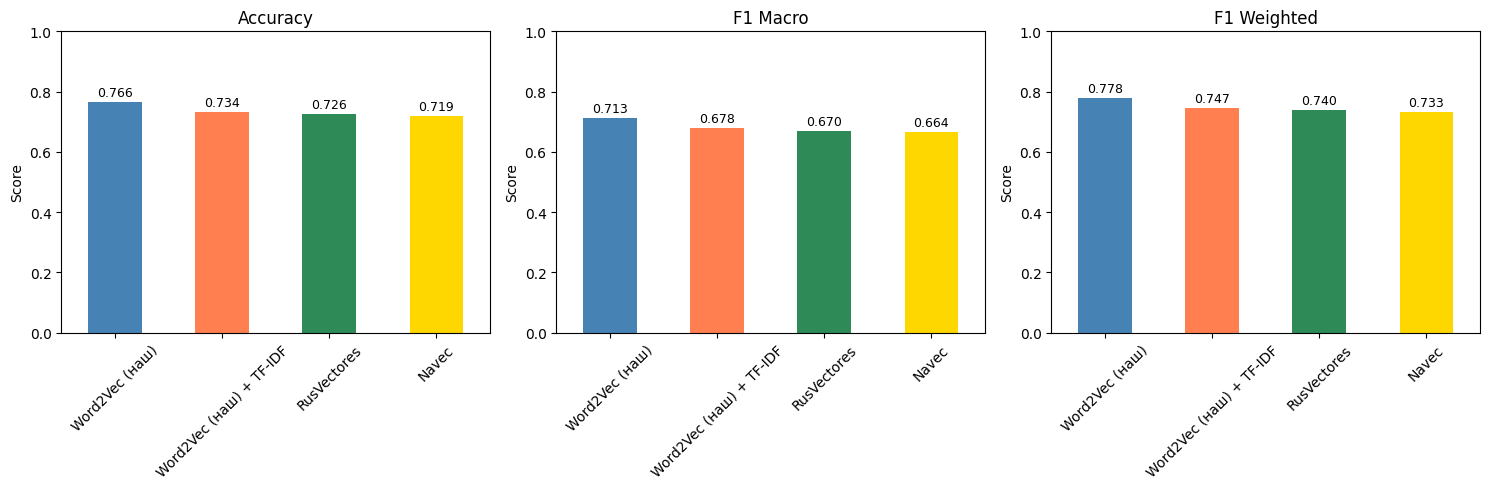

In [43]:
# Визуализация результатов
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['accuracy', 'f1_macro', 'f1_weighted']
titles = ['Accuracy', 'F1 Macro', 'F1 Weighted']

for ax, metric, title in zip(axes, metrics, titles):
    results_test_df[metric].plot(kind='bar', ax=ax, color=['steelblue', 'coral', 'seagreen', 'gold'])
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    
    # Добавляем значения на столбцы
    for i, v in enumerate(results_test_df[metric]):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [44]:
# Classification Report для лучшей модели
best_test_model_name = results_test_df.index[0]
print(f'\nClassification Report для лучшей модели ({best_test_model_name}):')

# Выбираем правильную модель и данные
if 'TF-IDF' in best_test_model_name:
    best_model = model_tfidf_w
    X_test_best = X_test_tfidf_w
elif 'Word2Vec' in best_test_model_name:
    best_model = model_w2v
    X_test_best = X_test_w2v
elif 'Navec' in best_test_model_name:
    best_model = model_navec
    X_test_best = X_test_navec
else:  # RusVectores
    best_model = model_rusv
    X_test_best = X_test_rusv

y_pred_best = best_model.predict(X_test_best)
print(classification_report(y_test, y_pred_best, target_names=label_encoder.classes_))


Classification Report для лучшей модели (Word2Vec (наш)):
                   precision    recall  f1-score   support

           Бизнес       0.21      0.70      0.32       192
      Бывший СССР       0.77      0.88      0.82      1366
              Дом       0.70      0.88      0.78       612
         Из жизни       0.52      0.72      0.60       767
   Интернет и СМИ       0.72      0.74      0.73      1231
         Культура       0.88      0.88      0.88      1506
              Мир       0.85      0.78      0.81      3690
  Наука и техника       0.84      0.79      0.81      1461
      Путешествия       0.38      0.85      0.53       184
           Россия       0.87      0.61      0.72      4159
Силовые структуры       0.32      0.70      0.44       549
            Спорт       0.97      0.95      0.96      1831
         Ценности       0.70      0.89      0.79       227
        Экономика       0.86      0.73      0.79      2225

         accuracy                           0.77     2

---

## 10. Выводы

### Методология

- **Word2Vec (наш)** обучен на **полном датасете** (~663k текстов) для максимального качества эмбеддингов
- **Классификатор** обучен на **100k выборке** (как в HW1) для корректного сравнения
- Это стандартная практика: эмбеддинги обучаются unsupervised, поэтому использование всех данных не создаёт data leakage

### Сравнение эмбеддингов на тестовой выборке

| Модель | Accuracy | F1 Macro | F1 Weighted | Описание |
|--------|----------|----------|-------------|----------|
| **Word2Vec (наш)** | **0.7659** | **0.7133** | **0.7778** | Обучен на 663k текстов Lenta.ru |
| Word2Vec + TF-IDF | 0.7338 | 0.6780 | 0.7470 | TF-IDF взвешивание эмбеддингов |
| RusVectores (Taiga) | 0.7258 | 0.6704 | 0.7401 | Смешанный корпус (4.8B токенов) |
| Navec | 0.7193 | 0.6645 | 0.7331 | Художественная литература (12B токенов) |

### Сравнение с HW1 (TF-IDF + LogisticRegression)

| Метрика | HW1 (TF-IDF) | HW2 (Word2Vec) | Разница |
|---------|--------------|----------------|---------|
| Accuracy | 0.8256 | 0.7659 | **-0.060** |
| F1 Macro | 0.7931 | 0.7133 | **-0.080** |
| F1 Weighted | 0.8266 | 0.7778 | **-0.049** |

### Основные наблюдения

1. **Собственный Word2Vec превосходит предобученные модели:**
   - Обучение на domain-specific данных (663k новостей Lenta.ru) дало лучшие результаты
   - RusVectores и Navec уступают ~4-5% по F1 Macro
   - Это подтверждает важность domain adaptation для эмбеддингов

2. **TF-IDF взвешивание ухудшило результаты (F1 Macro: 0.713 → 0.678, -3.5%):**
   
   Это связано с **фундаментальным конфликтом целей** TF-IDF и Word2Vec:
   - **TF-IDF** даёт высокий вес **редким** словам (высокий IDF)
   - **Word2Vec** даёт **качественные** эмбеддинги **частым** словам (больше контекстов при обучении)
   - **Итог:** TF-IDF усиливает влияние слов с шумными, менее качественными векторами
   
   Дополнительные причины:
   - Простое усреднение работает как сглаживание шума — все слова равноправны
   - TF-IDF нарушает это сглаживание, давая непропорциональный вес отдельным словам
   - L2-нормализация в sklearn TfidfVectorizer искажает веса в зависимости от длины документа

3. **TF-IDF из HW1 превосходит Word2Vec:**
   - TF-IDF показал accuracy 0.826 против 0.766 у Word2Vec (-6%)
   - Для классификации новостей важно *какие* слова встречаются, а не их *семантика*
   - TF-IDF лучше сохраняет дискриминативную информацию о терминах-маркерах категорий
   - Размерность: TF-IDF использует ~150k признаков против 300 у Word2Vec

4. **Качество эмбеддингов (intrinsic evaluation) хорошее:**
   - `most_similar` корректно находит семантически близкие слова
   - `doesnt_match` правильно определяет лишние слова во всех 4 тестах
   - Аналогии работают: "путин - россия + обама = барак, трамп, буш"

### Почему TF-IDF лучше для классификации новостей?

1. **Специфика задачи:** классификация по топикам опирается на ключевые слова-маркеры ("футбол" → Спорт, "рубль" → Экономика). TF-IDF явно выделяет такие термины
2. **Потеря информации при усреднении:** Word2Vec усредняет сотни слов в один вектор 300d, теряя информацию о наличии конкретных терминов
3. **Bag-of-words природа задачи:** для тематической классификации порядок слов и семантические связи менее важны, чем набор ключевых слов

### Рекомендации для улучшения Word2Vec подхода

1. **Конкатенация признаков:** объединить TF-IDF и Word2Vec эмбеддинги
2. **SIF (Smooth Inverse Frequency):** более теоретически обоснованное взвешивание с формулой a/(a + p(w)), где p(w) — частота слова
3. **Doc2Vec:** использовать модель, которая напрямую учит представления документов
4. **Нейросетевой классификатор:** LSTM/CNN поверх эмбеддингов вместо LogisticRegression